---
# authors:
#   - name: Vance Russell
#     affiliations:
#       - 3point.xyz
abstract: |
  A guide to understanding your data through exploratory data analysis (EDA) that includes systematic exploration, visualization, and statistical analysis. The chapter runs through an EDA workflow showing how to use various analysis packages, visualize data to show where problems may lie, and creates a report exportable as HTML.
exports:
    - format: typst
      template: lapreprint-typst
      output: export/04-eda.pdf 
--- 

# 4. EDA
EDA is the critical first step in any data analysis project. It involves:

- **Understanding structure** - How is the data organized?
- **Identifying patterns** - What trends or relationships exist?
- **Detecting anomalies** - Are there outliers or errors?
- **Assessing data quality** - Missing values, duplicates, inconsistencies?
- **Generating hypotheses** - What insights might be worth investigating?

The process is iterative and visual, and will likely involve some data cleaning before data is ready for analaysis.

## EDA Packages
Core tools for EDA include data analysis and profiling tools such as pandas, numpy, matplotlib, yadata-profiling, and missingno {numref}`packages`. R is also a great software platform for data analysis and EDA. The DataExplorer package quickly analyzes data and produces an HTML report. The closest Python equivalent is ydata-profiling that can also generate HTML reports.

:::{table} Python packages for EDA and R equivalents.
:label: packages
:align: center

| Package | Purpose | R Equivalent |
|---------|---------|--------------|
| **pandas** | Data loading, manipulation, basic profiling | base R, dplyr |
| **numpy** | Numerical computations, statistics | base R |
| **matplotlib, seaborn** | Visualization | ggplot2, base graphics |
| **ydata-profiling** | Automated profiling reports | DataExplorer |
| **missingno** | Missing value visualization | vis_miss() |

:::

## Sample workflow
Let's run through an example EDA workflow using a variety of packages and visualizations. We'll first import dependencies then create a sample dataset.

In [2]:
# Import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Optional: Uncomment if you have ydata-profiling installed
# from ydata_profiling import ProfileReport

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [3]:
# Create a realistic environmental monitoring dataset
np.random.seed(42)
n_samples = 200

data = {
    'Site_ID': [f'SITE_{i:03d}' for i in range(1, n_samples + 1)],
    'Year': np.random.choice([2020, 2021, 2022, 2023], n_samples),
    'Latitude': np.random.uniform(35, 40, n_samples),
    'Longitude': np.random.uniform(-120, -115, n_samples),
    'Elevation_m': np.random.normal(2000, 500, n_samples),
    'Temperature_C': np.random.normal(15, 5, n_samples),
    'Precipitation_mm': np.random.exponential(50, n_samples),
    'Forest_Cover_%': np.random.normal(60, 20, n_samples),
    'Population_Density': np.random.exponential(100, n_samples),
    'Protected_Status': np.random.choice(['Protected', 'Unprotected', 'Buffer'], n_samples),
    'Land_Use': np.random.choice(['Forest', 'Agricultural', 'Urban', 'Shrubland'], n_samples)
}

df = pd.DataFrame(data)

# Introduce some missing values
df.loc[np.random.choice(df.index, 10), 'Temperature_C'] = np.nan
df.loc[np.random.choice(df.index, 8), 'Precipitation_mm'] = np.nan
df.loc[np.random.choice(df.index, 5), 'Forest_Cover_%'] = np.nan

# Add some duplicates
df = pd.concat([df, df.iloc[:5]], ignore_index=True)

print(f"Dataset created: {df.shape[0]} rows × {df.shape[1]} columns")
print(df.head())

Dataset created: 205 rows × 11 columns
    Site_ID  Year   Latitude   Longitude  Elevation_m  Temperature_C  \
0  SITE_001  2022  35.157146 -119.741591  2170.877988      12.703196   
1  SITE_002  2023  38.182052 -117.343227  2938.085420      10.750778   
2  SITE_003  2020  36.571780 -117.296824  2475.211919      19.151679   
3  SITE_004  2022  37.542853 -116.812850  1711.548172      10.719581   
4  SITE_005  2022  39.537832 -116.369543  1550.792664      15.357831   

   Precipitation_mm  Forest_Cover_%  Population_Density Protected_Status  \
0         58.927692       48.896009          204.603346      Unprotected   
1         94.588599       97.623141          152.503006      Unprotected   
2         14.361976       31.039722           83.705511      Unprotected   
3         33.610883       16.023881          134.112679        Protected   
4         12.500656       68.800289          210.796910           Buffer   

       Land_Use  
0         Urban  
1  Agricultural  
2     Shrubland  

Printing df.head gives you an initial glimpse of the data and fields in a tabular format. We'll look at data structure next.

In [4]:
# Basic shape and structure
print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)
print(f"Shape: {df.shape} ({df.shape[0]} rows, {df.shape[1]} columns)")
print(f"\nColumn Names and Types:")
print(df.dtypes)

# More detailed info
print("\n" + "=" * 60)
print("DETAILED INFO")
print("=" * 60)
df.info()

# First and last rows
print("\n" + "=" * 60)
print("FIRST FEW ROWS")
print("=" * 60)
print(df.head())

print("\nLAST FEW ROWS")
print(df.tail())

DATASET STRUCTURE
Shape: (205, 11) (205 rows, 11 columns)

Column Names and Types:
Site_ID                object
Year                    int64
Latitude              float64
Longitude             float64
Elevation_m           float64
Temperature_C         float64
Precipitation_mm      float64
Forest_Cover_%        float64
Population_Density    float64
Protected_Status       object
Land_Use               object
dtype: object

DETAILED INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Site_ID             205 non-null    object 
 1   Year                205 non-null    int64  
 2   Latitude            205 non-null    float64
 3   Longitude           205 non-null    float64
 4   Elevation_m         205 non-null    float64
 5   Temperature_C       196 non-null    float64
 6   Precipitation_mm    197 non-null    float64
 7   Forest_

This is so exciting! The first dataset structure table is critical to understand the types of data in your dataset. One of the most common problems in datasets are fields assigned text values when they should be integers or vice versa. 

Missing data can bias results or reduce sample size. Always investigate!

### Summary Statistics


In [5]:
# Missing value analysis
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

# Count and percentage
missing = pd.DataFrame({
    'Count': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Count'] > 0].sort_values('Count', ascending=False)

if len(missing) > 0:
    print(missing)
else:
    print("No missing values found (but we introduced some, so they should appear)")

# Total missing
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
print(f"\nTotal missing cells: {total_missing} / {total_cells} ({total_missing/total_cells*100:.2f}%)")

# Duplicates
print("\n" + "=" * 60)
print("DUPLICATES")
print("=" * 60)
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"\nDuplicate rows:")
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

MISSING VALUES
                  Count  Percentage
Temperature_C         9        4.39
Precipitation_mm      8        3.90
Forest_Cover_%        5        2.44

Total missing cells: 22 / 2255 (0.98%)

DUPLICATES
Duplicate rows: 5

Duplicate rows:
      Site_ID  Year   Latitude   Longitude  Elevation_m  Temperature_C  \
0    SITE_001  2022  35.157146 -119.741591  2170.877988      12.703196   
200  SITE_001  2022  35.157146 -119.741591  2170.877988      12.703196   
1    SITE_002  2023  38.182052 -117.343227  2938.085420      10.750778   
201  SITE_002  2023  38.182052 -117.343227  2938.085420      10.750778   
2    SITE_003  2020  36.571780 -117.296824  2475.211919      19.151679   
202  SITE_003  2020  36.571780 -117.296824  2475.211919      19.151679   
3    SITE_004  2022  37.542853 -116.812850  1711.548172      10.719581   
203  SITE_004  2022  37.542853 -116.812850  1711.548172      10.719581   
4    SITE_005  2022  39.537832 -116.369543  1550.792664      15.357831   
204  SITE_005 

### Missingno

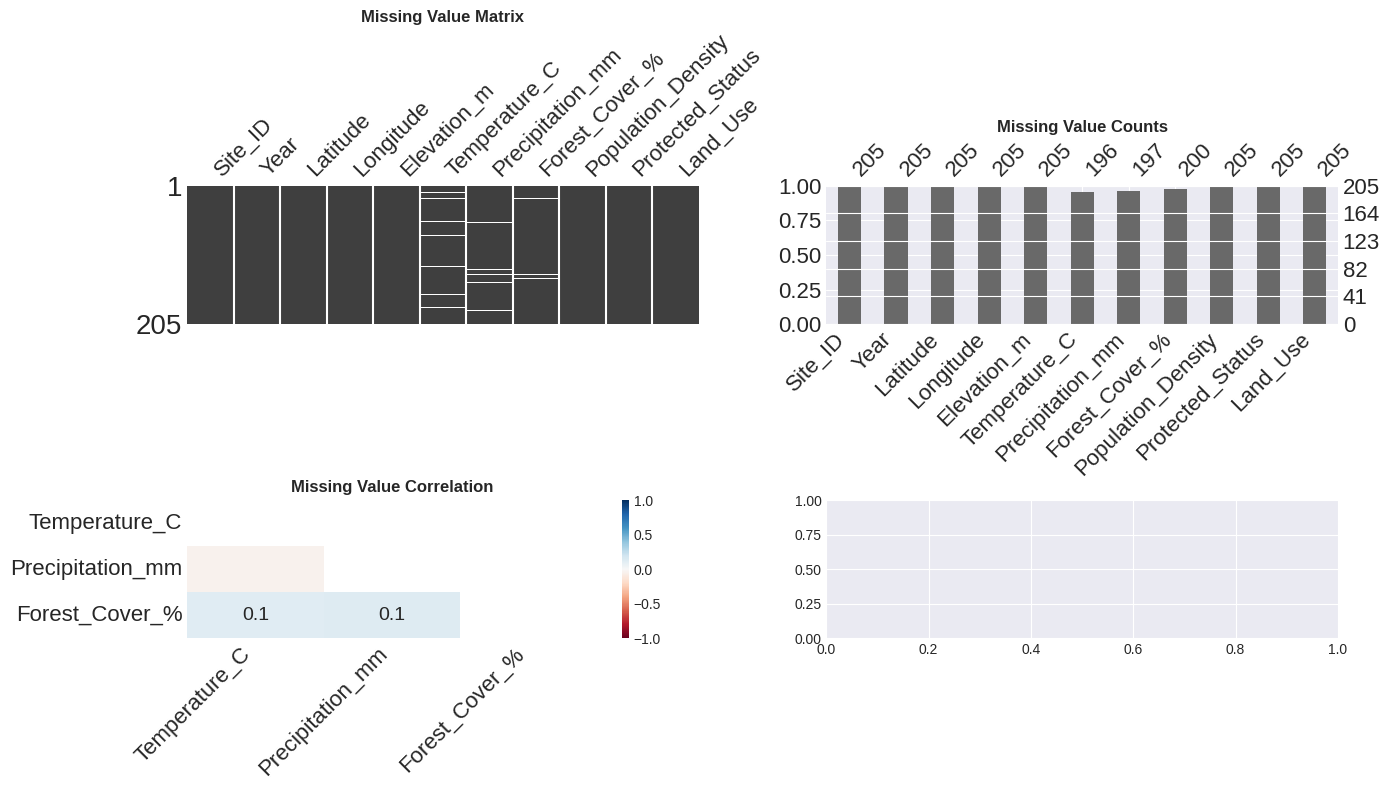

Interpretation:
- Matrix: White lines show missing data locations
- Bar: Heights show how many values are present in each column
- Heatmap: Shows which missing values tend to occur together


In [6]:
# Visualize missing values
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Matrix visualization - shows missing pattern
plt.subplot(2, 2, 1)
msno.matrix(df, ax=plt.gca(), sparkline=False)
plt.title('Missing Value Matrix', fontweight='bold')

# Bar chart - shows count by column
plt.subplot(2, 2, 2)
msno.bar(df, ax=plt.gca())
plt.title('Missing Value Counts', fontweight='bold')

# Heatmap - shows correlation of missingness
plt.subplot(2, 2, 3)
msno.heatmap(df, ax=plt.gca())
plt.title('Missing Value Correlation', fontweight='bold')

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Matrix: White lines show missing data locations")
print("- Bar: Heights show how many values are present in each column")
print("- Heatmap: Shows which missing values tend to occur together")

### Descriptive statistics.


In [7]:
# Statistical summary of numerical columns
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
print(df.describe().round(2))

# Get specific statistics
print("\n" + "=" * 60)
print("SKEWNESS AND KURTOSIS")
print("=" * 60)
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"{col:25} - Skewness: {skew:7.2f}  |  Kurtosis: {kurt:7.2f}")

# Categorical summary
print("\n" + "=" * 60)
print("CATEGORICAL VARIABLES")
print("=" * 60)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")

DESCRIPTIVE STATISTICS
          Year  Latitude  Longitude  Elevation_m  Temperature_C  \
count   205.00    205.00     205.00       205.00         196.00   
mean   2021.59     37.54    -117.48      1976.70          15.08   
std       1.12      1.46       1.52       515.26           5.00   
min    2020.00     35.03    -119.95       764.18           1.52   
25%    2021.00     36.25    -118.75      1603.56          11.77   
50%    2022.00     37.59    -117.36      1972.23          15.08   
75%    2023.00     38.81    -116.23      2316.39          18.49   
max    2023.00     39.95    -115.04      3539.44          28.16   

       Precipitation_mm  Forest_Cover_%  Population_Density  
count            197.00          200.00              205.00  
mean              57.31           61.68               99.03  
std               55.06           19.81               95.00  
min                0.32            2.07                0.58  
25%               14.36           48.97               32.04  
5

### Distribution analysis
and visualizing distributions


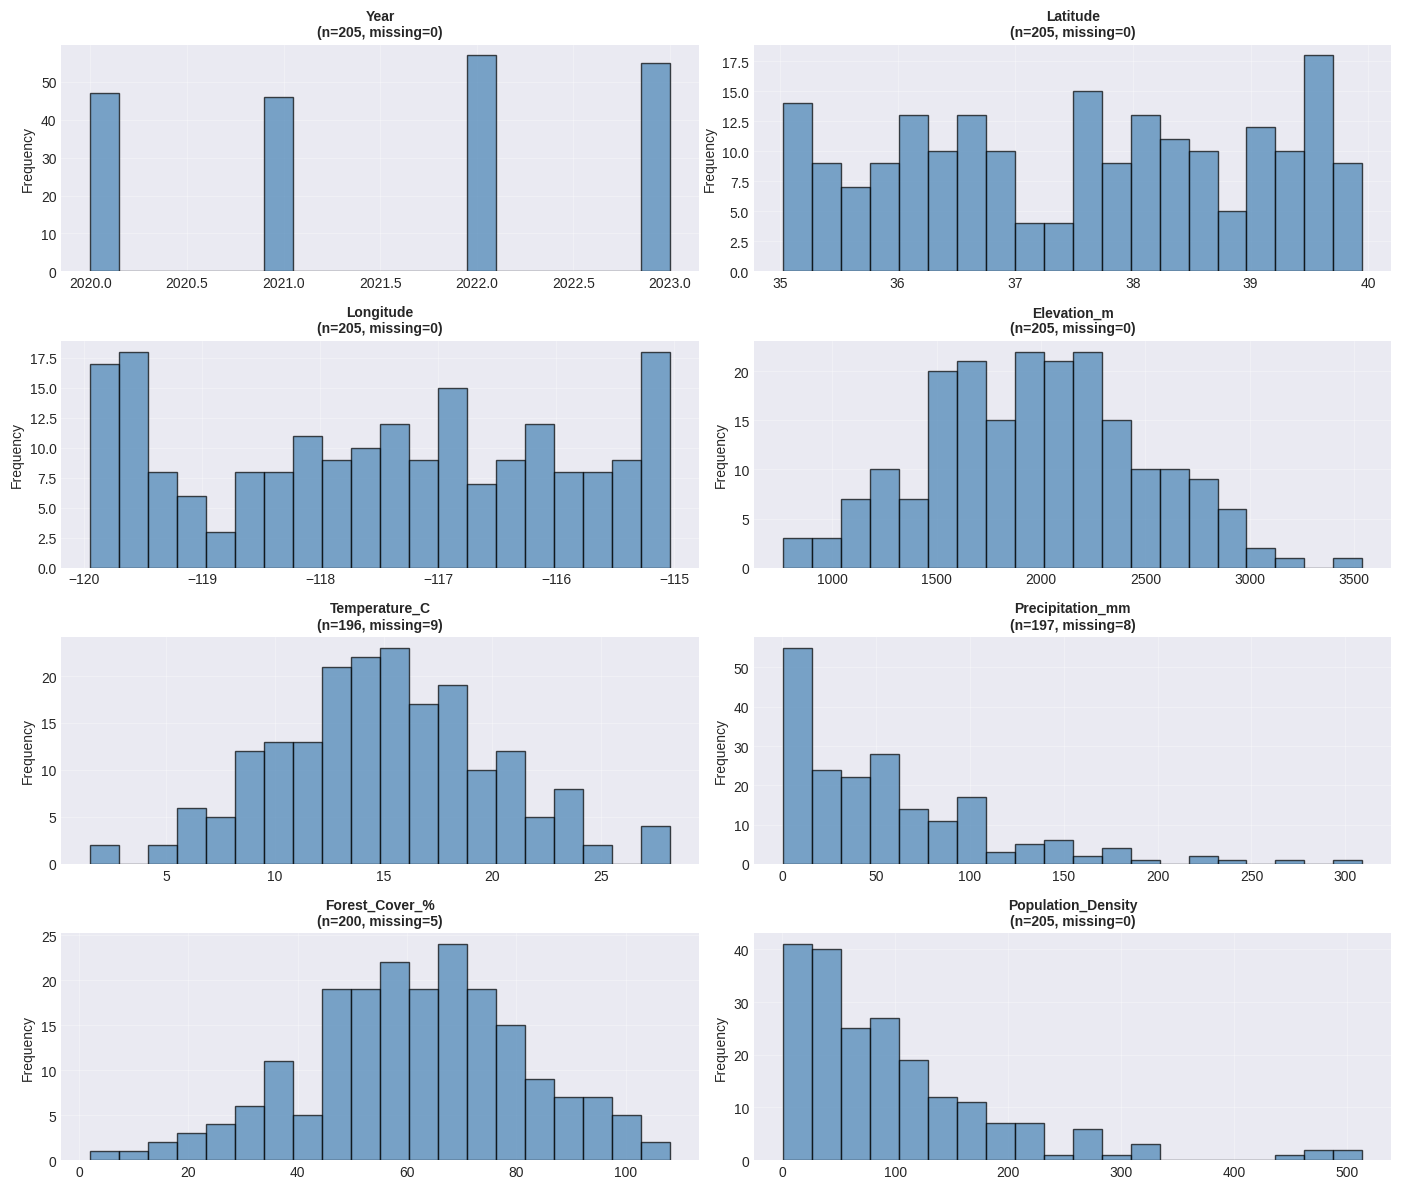

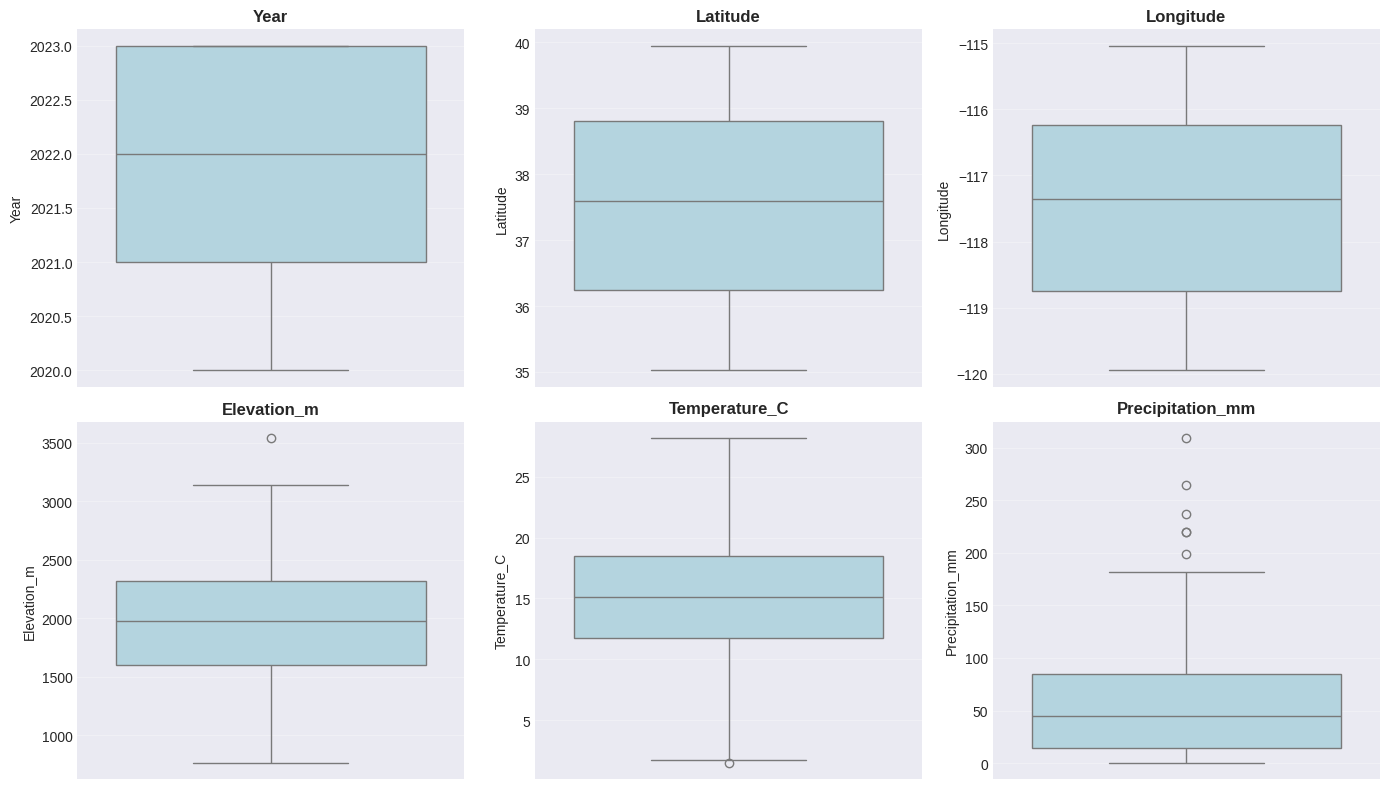

Interpretation:
- Histograms show the distribution shape
- Box plots show median, quartiles, and potential outliers
- Points beyond whiskers may be outliers worth investigating


In [8]:
# Create histograms and box plots for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:8]):
    # Histogram with KDE
    axes[idx].hist(df[col].dropna(), bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{col}\n(n={df[col].notna().sum()}, missing={df[col].isna().sum()})', 
                        fontweight='bold', fontsize=10)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Box plots for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:6]):
    sns.boxplot(y=df[col], ax=axes[idx], color='lightblue')
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Histograms show the distribution shape")
print("- Box plots show median, quartiles, and potential outliers")
print("- Points beyond whiskers may be outliers worth investigating")

### Correlation matrix


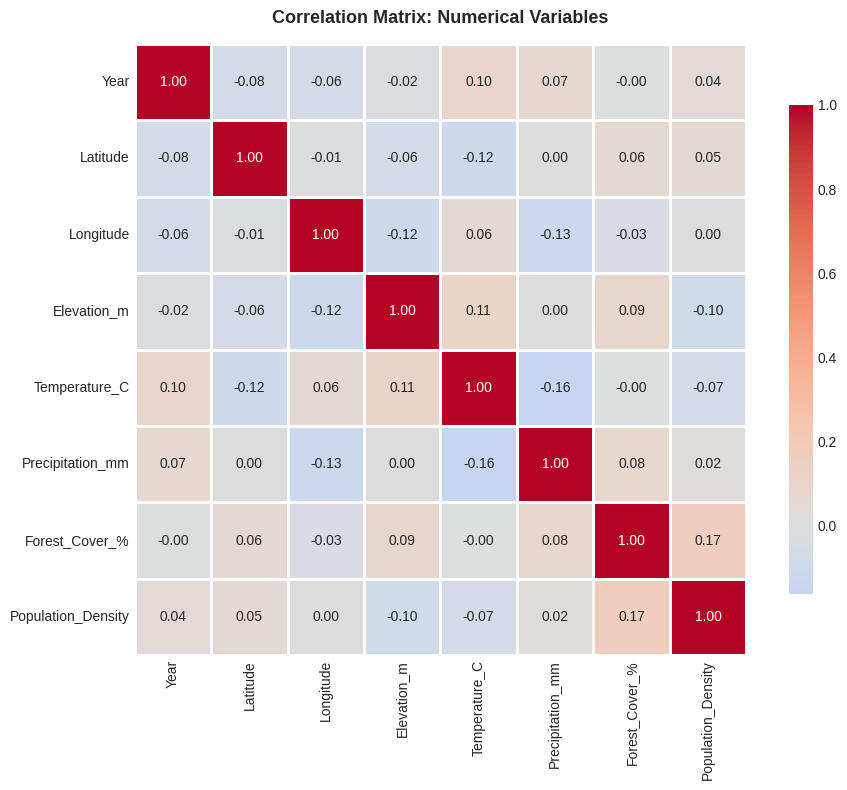

STRONGEST CORRELATIONS
       Variable1          Variable2  Correlation
  Forest_Cover_% Population_Density     0.166868
   Temperature_C   Precipitation_mm    -0.163705
       Longitude   Precipitation_mm    -0.125927
        Latitude      Temperature_C    -0.119565
       Longitude        Elevation_m    -0.115227
     Elevation_m      Temperature_C     0.114732
            Year      Temperature_C     0.102317
     Elevation_m Population_Density    -0.095198
     Elevation_m     Forest_Cover_%     0.086845
Precipitation_mm     Forest_Cover_%     0.084183


In [9]:
# Calculate correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Heatmap visualization
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix: Numerical Variables', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Find strongest correlations (excluding diagonal)
print("=" * 60)
print("STRONGEST CORRELATIONS")
print("=" * 60)

# Get correlations above threshold (excluding 1.0)
corr_list = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_list.append({
            'Variable1': corr_matrix.columns[i],
            'Variable2': corr_matrix.columns[j],
            'Correlation': corr_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_list).sort_values('Correlation', key=abs, ascending=False)
print(corr_df.head(10).to_string(index=False))

### ydata-profiling
The `ydata-profiling` package is the Python equivalent of R's DataExplorer. It generates comprehensive HTML reports with one line of code.

In [12]:
# Example: Automated profiling with ydata-profiling
# Uncomment below to run (requires: pip install ydata-profiling)

"""
from ydata_profiling import ProfileReport

# Generate profile report
profile = ProfileReport(df, title="Environmental Data Profile", minimal=False)

# Save to HTML file
profile.to_file("eda_report.html")

# Or display in Jupyter
# profile.to_notebook_iframe()
"""

# Manual equivalent when ydata-profiling is not available
print("=" * 60)
print("EDA SUMMARY (Manual Alternative to ydata-profiling)")
print("=" * 60)

summary = {
    'Total Rows': len(df),
    'Total Columns': len(df.columns),
    'Numeric Columns': len(df.select_dtypes(include=[np.number]).columns),
    'Categorical Columns': len(df.select_dtypes(include=['object']).columns),
    'Total Missing': df.isnull().sum().sum(),
    'Duplicate Rows': df.duplicated().sum(),
    'Memory Usage (MB)': df.memory_usage(deep=True).sum() / 1024**2
}

for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key:.<35} {value:.2f}")
    else:
        print(f"{key:.<35} {value}")

EDA SUMMARY (Manual Alternative to ydata-profiling)
Total Rows......................... 205
Total Columns...................... 11
Numeric Columns.................... 8
Categorical Columns................ 3
Total Missing...................... 22
Duplicate Rows..................... 5
Memory Usage (MB).................. 0.05


### Categorical Data Analysis

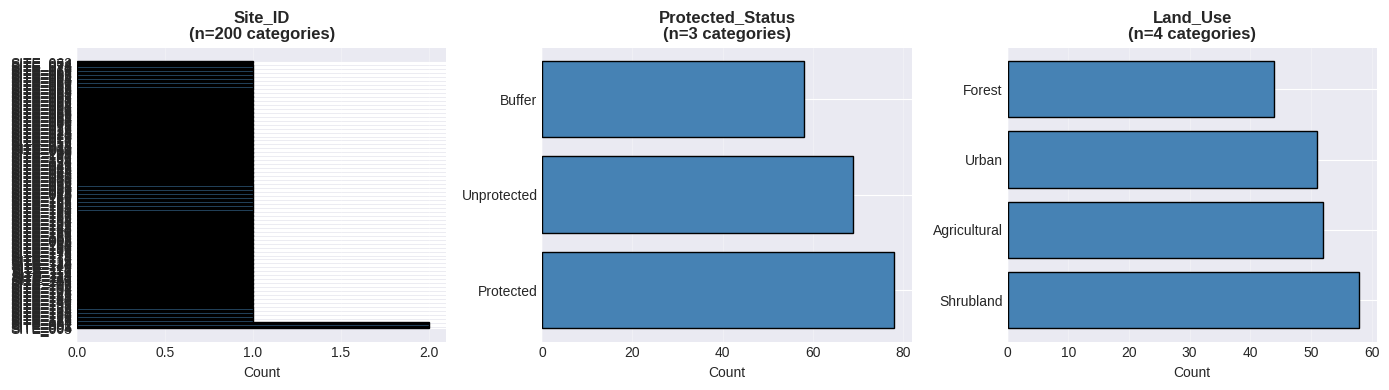

CROSSTAB: Protected_Status × Land_Use
Land_Use          Agricultural  Forest  Shrubland  Urban  All
Protected_Status                                             
Buffer                      17      10         18     13   58
Protected                   18      21         19     20   78
Unprotected                 17      13         21     18   69
All                         52      44         58     51  205


In [13]:
# Categorical data visualization
categorical_cols = df.select_dtypes(include=['object']).columns

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(14, 4))
if len(categorical_cols) == 1:
    axes = [axes]

for idx, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    axes[idx].barh(value_counts.index, value_counts.values, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{col}\n(n={len(value_counts)} categories)', fontweight='bold')
    axes[idx].set_xlabel('Count')
    axes[idx].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Cross-tabulation analysis
print("=" * 60)
print("CROSSTAB: Protected_Status × Land_Use")
print("=" * 60)
if 'Protected_Status' in df.columns and 'Land_Use' in df.columns:
    crosstab = pd.crosstab(df['Protected_Status'], df['Land_Use'], margins=True)
    print(crosstab)

### EDA function


In [11]:
def quick_eda(df, name="Dataset"):
    """
    Perform quick EDA on a DataFrame
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset to analyze
    name : str
        Name of the dataset for reporting
    """
    print(f"\n{'='*70}")
    print(f"EXPLORATORY DATA ANALYSIS: {name}")
    print(f"{'='*70}\n")
    
    # Shape and types
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")
    
    # Missing values
    missing_pct = (df.isnull().sum() / len(df) * 100)
    if missing_pct.sum() > 0:
        print("Missing Values:")
        print(missing_pct[missing_pct > 0].sort_values(ascending=False))
        print()
    
    # Duplicates
    print(f"Duplicates: {df.duplicated().sum()}")
    
    # Data types
    print("\nData Types:")
    print(df.dtypes.value_counts())
    
    # Numerical summary
    print("\n" + "-"*70)
    print("NUMERICAL VARIABLES")
    print("-"*70)
    print(df.describe().round(2))
    
    # Categorical summary
    cat_cols = df.select_dtypes(include=['object']).columns
    if len(cat_cols) > 0:
        print("\n" + "-"*70)
        print("CATEGORICAL VARIABLES")
        print("-"*70)
        for col in cat_cols:
            print(f"\n{col}: {df[col].nunique()} unique values")
            print(df[col].value_counts().head(3))
    
    print(f"\n{'='*70}\n")

# Test the function
quick_eda(df, name="Environmental Monitoring Data")


EXPLORATORY DATA ANALYSIS: Environmental Monitoring Data

Shape: 205 rows × 11 columns
Memory: 0.05 MB

Missing Values:
Temperature_C       4.390244
Precipitation_mm    3.902439
Forest_Cover_%      2.439024
dtype: float64

Duplicates: 5

Data Types:
float64    7
object     3
int64      1
Name: count, dtype: int64

----------------------------------------------------------------------
NUMERICAL VARIABLES
----------------------------------------------------------------------
          Year  Latitude  Longitude  Elevation_m  Temperature_C  \
count   205.00    205.00     205.00       205.00         196.00   
mean   2021.59     37.54    -117.48      1976.70          15.08   
std       1.12      1.46       1.52       515.26           5.00   
min    2020.00     35.03    -119.95       764.18           1.52   
25%    2021.00     36.25    -118.75      1603.56          11.77   
50%    2022.00     37.59    -117.36      1972.23          15.08   
75%    2023.00     38.81    -116.23      2316.39    